# Customer Churn Prediction — CRISP-DM Data Science Project

**Course level:** Master's-level Data Science  
**Methodology:** CRISP-DM (Cross-Industry Standard Process for Data Mining)  
**Dataset:** Telco Customer Churn (`WA_Fn-UseC_-Telco-Customer-Churn(4).csv`)

## Project objective

> Develop a robust binary classification system that predicts whether a telecommunications customer will churn and translate the model results into actionable customer-retention decisions.

This notebook consolidates the analysis performed during the project. The code, reported values, visualizations, model results, and conclusions reflect the analysis already completed.

### CRISP-DM structure

1. **Business Understanding**
2. **Data Understanding**
3. **Data Preparation**
4. **Modeling**
5. **Evaluation**
6. **Business Recommendation**

### Important modeling principle

The test set is kept separate from model-development decisions. Cross-validation and out-of-fold predictions are used for model selection, hyperparameter tuning, and threshold selection; the held-out test set is then used for the final evaluation.


## 1. Business Understanding

### Business problem

Customer churn represents the loss of an existing telecommunications customer. A predictive churn model can support retention activities by identifying customers who are more likely to discontinue service.

### Data-science objective

This is a **supervised binary classification problem**:

\[
P(\mathrm{Churn}=\mathrm{Yes}\mid X)
\]

The target variable is `Churn`, with:

- `Yes` = customer churned
- `No` = customer did not churn

### Business success criteria

Accuracy alone is insufficient because the target is imbalanced. The project therefore emphasizes:

- Precision
- Recall
- F1-score
- ROC-AUC
- Precision-recall behavior
- Confusion matrix
- Business trade-offs between false positives and false negatives

For retention, **recall for the churn class is especially important**, because missing a customer who is likely to leave can represent a lost intervention opportunity.


## 2. Data Understanding

In [ ]:
import pandas as pd

DATA_PATH = "/mnt/data/WA_Fn-UseC_-Telco-Customer-Churn(4).csv"
df = pd.read_csv(DATA_PATH)

print(df.shape)
print(df.head().to_string(index=False))


(7043, 21)


customerID gender  SeniorCitizen Partner Dependents  tenure PhoneService    MultipleLines InternetService OnlineSecurity OnlineBackup DeviceProtection TechSupport StreamingTV StreamingMovies       Contract PaperlessBilling             PaymentMethod  MonthlyCharges TotalCharges Churn
7590-VHVEG Female              0     Yes         No       1           No No phone service             DSL             No          Yes               No          No          No              No Month-to-month              Yes          Electronic check           29.85        29.85    No
5575-GNVDE   Male              0      No         No      34           Yes               No             DSL            Yes           No              Yes          No          No              No       One year               No              Mailed check           56.95       1889.5    No
3668-QPYBK   Male              0      No         No       2           Yes               No             DSL            Yes          Yes             

In [ ]:
print(df.dtypes.to_string())


customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService          object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object


### Initial data-quality findings

- The dataset contains **7,043 customers and 21 original variables**.
- `TotalCharges` is initially stored as `object` rather than numeric.
- `customerID` is a unique identifier and is not used as a predictive feature.
- The target is imbalanced: **26.54% churn and 73.46% no churn**.
- Blank `TotalCharges` entries are hidden as whitespace strings and require explicit numeric conversion.


       count    pct
Churn
No      5174  73.46
Yes     1869  26.54


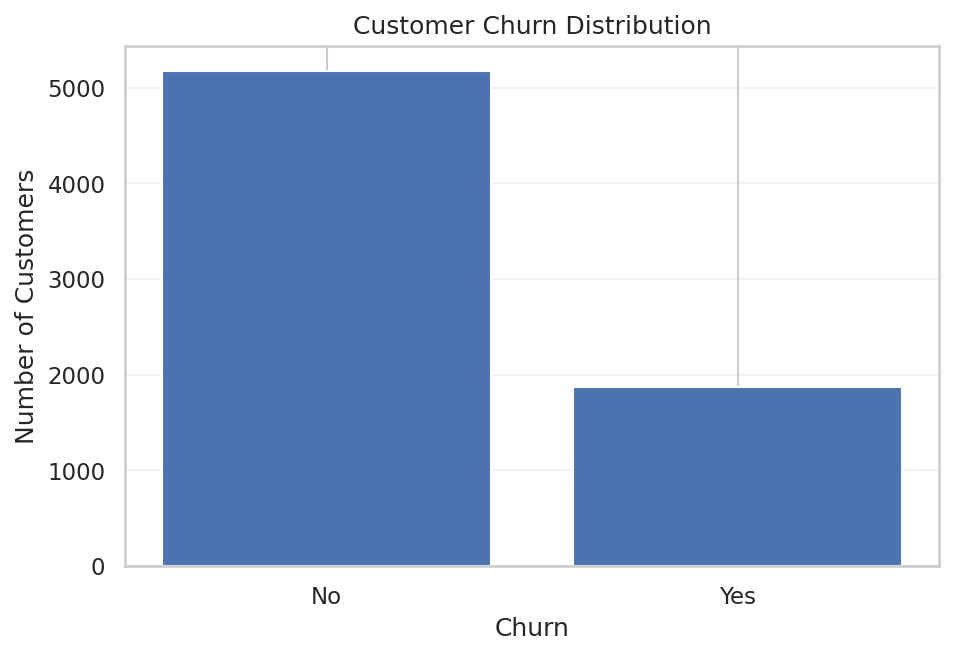

In [ ]:
td = df["Churn"].value_counts().to_frame("count")
td["pct"] = (td["count"] / len(df) * 100).round(2)
print(td)


In [ ]:
print(
    df[["SeniorCitizen", "tenure", "MonthlyCharges"]]
    .describe()
    .round(2)
)


       SeniorCitizen   tenure  MonthlyCharges
count        7043.00  7043.00         7043.00
mean            0.16    32.37           64.76
std             0.37    24.56           30.09
min             0.00     0.00           18.25
25%             0.00     9.00           35.50
50%             0.00    29.00           70.35
75%             0.00    55.00           89.85
max             1.00    72.00          118.75


### Exploratory Data Analysis

Contract
Month-to-month    42.71
One year          11.27
Two year           2.83


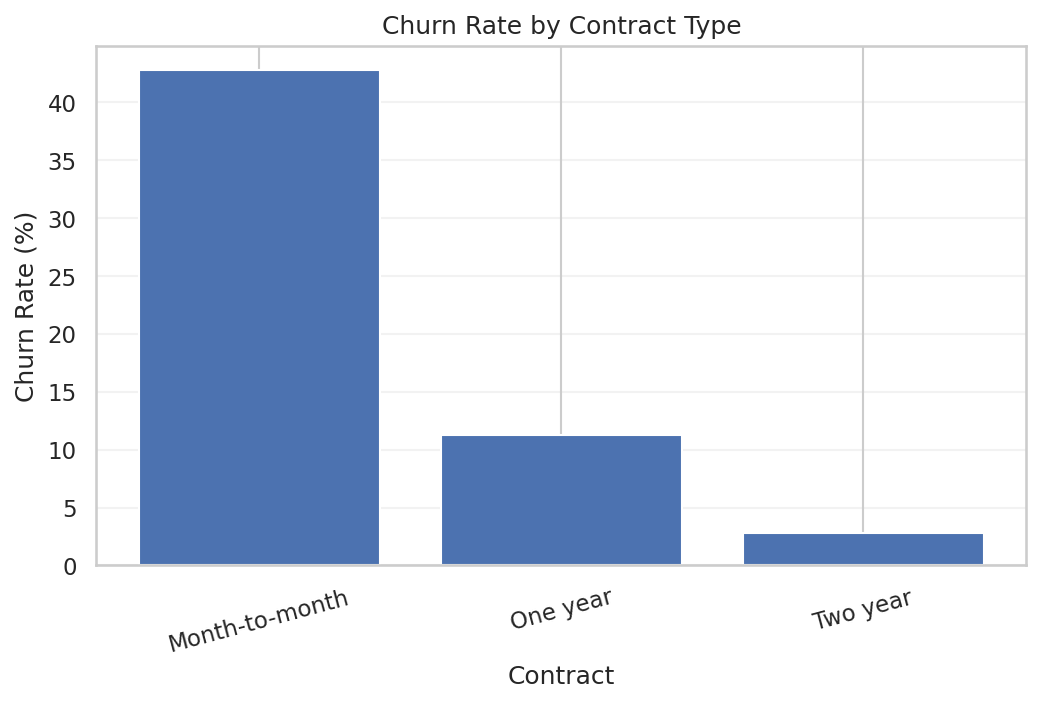

In [ ]:
contract_summary = (
    df.groupby("Contract")["Churn"]
      .apply(lambda s: (s == "Yes").mean() * 100)
)
print(contract_summary.round(2))


TenureGroup
0–6     52.94
7–12    35.89
13–24   28.71
25–48   20.39
49–72    9.51
Name: Churn, dtype: float64


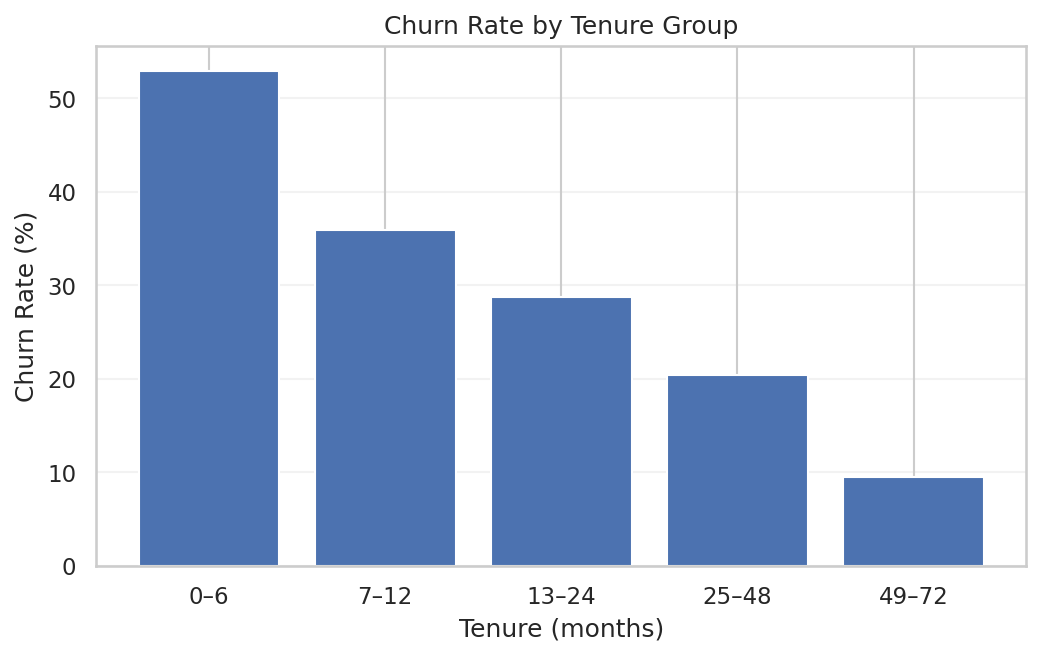

In [ ]:
df_eda = df.copy()
df_eda["TenureGroup"] = pd.cut(
    df_eda["tenure"],
    bins=[-1, 6, 12, 24, 48, 72],
    labels=["0–6", "7–12", "13–24", "25–48", "49–72"]
)

tenure_churn = (
    df_eda.groupby("TenureGroup", observed=False)["Churn"]
    .apply(lambda s: (s == "Yes").mean() * 100)
)
print(tenure_churn.round(2))


InternetService
DSL            18.96
Fiber optic    41.89
No              7.40
Name: Churn, dtype: float64


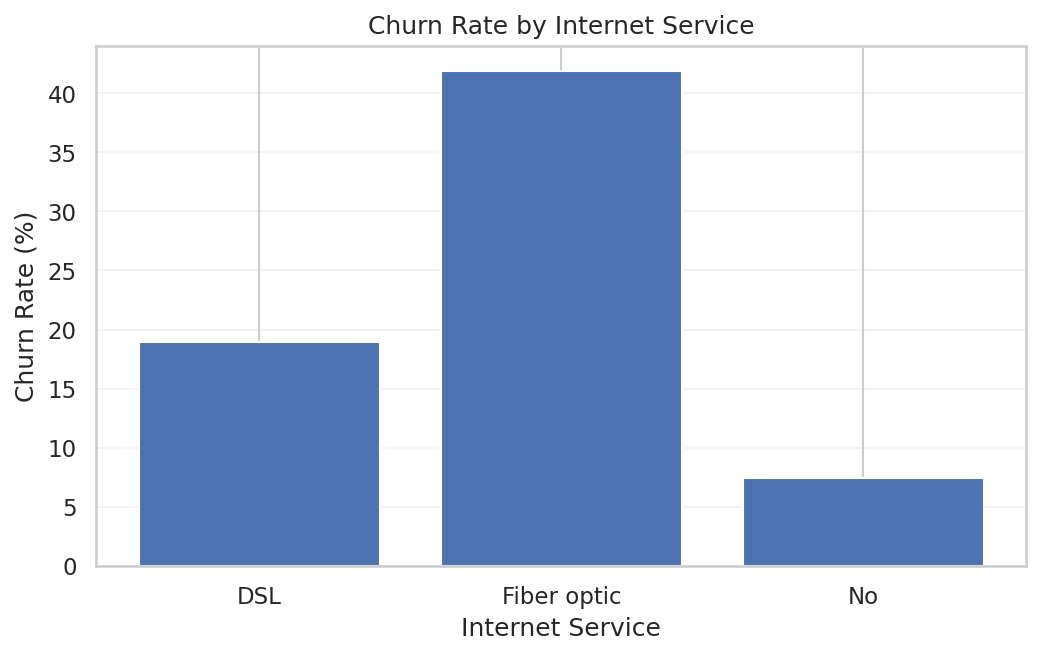

In [ ]:
internet_churn = (
    df.groupby("InternetService")["Churn"]
      .apply(lambda s: (s == "Yes").mean() * 100)
)
print(internet_churn.round(2))


PaymentMethod
Electronic check             45.29
Mailed check                  19.11
Bank transfer (automatic)    16.71
Credit card (automatic)      15.24
Name: Churn, dtype: float64


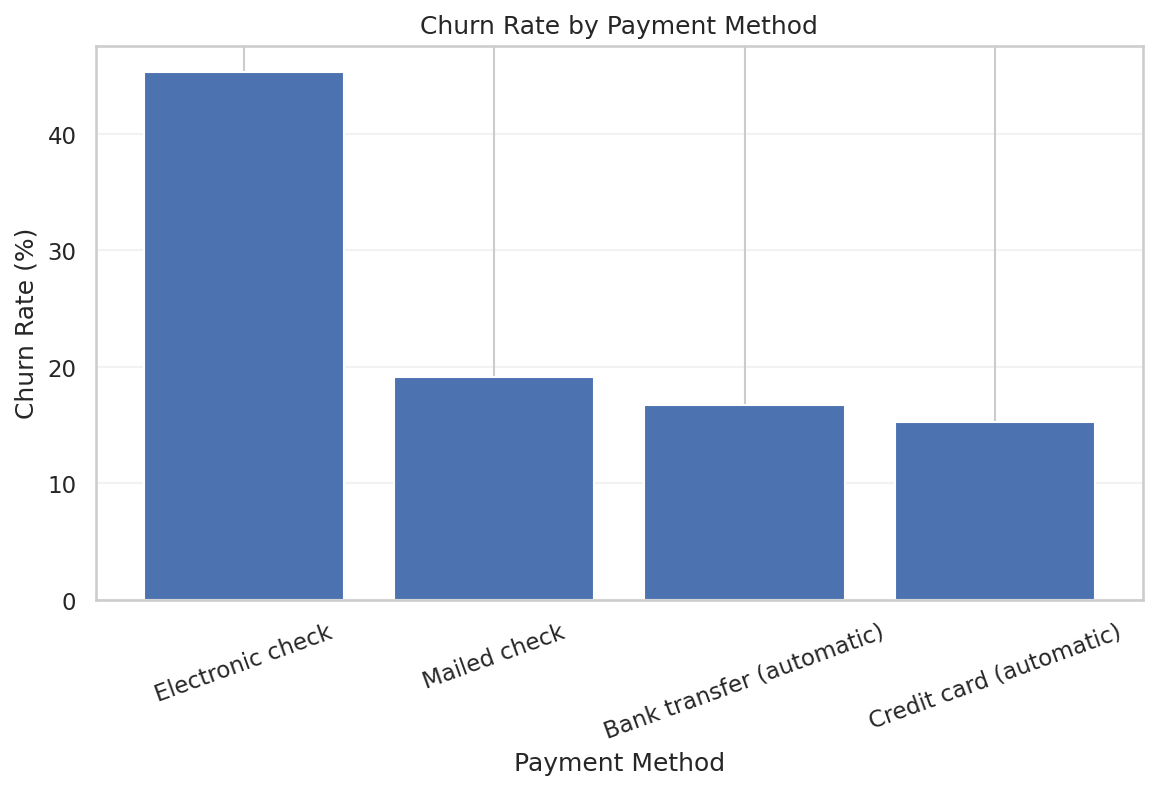

In [ ]:
payment_churn = (
    df.groupby("PaymentMethod")["Churn"]
      .apply(lambda s: (s == "Yes").mean() * 100)
)
print(payment_churn.round(2))


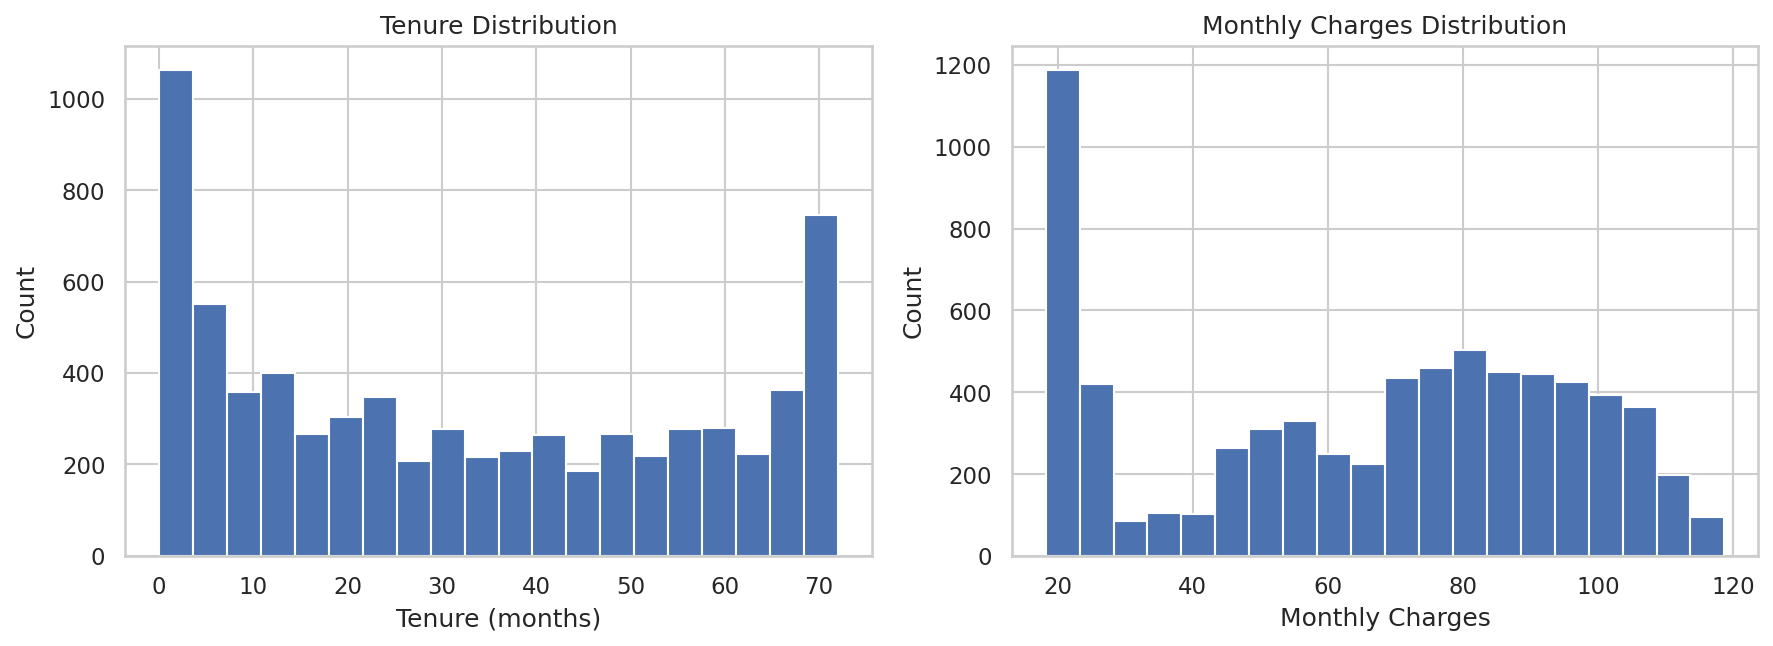

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].hist(df["tenure"], bins=20)
axes[0].set_title("Tenure Distribution")
axes[0].set_xlabel("Tenure (months)")
axes[0].set_ylabel("Count")

axes[1].hist(df["MonthlyCharges"], bins=20)
axes[1].set_title("Monthly Charges Distribution")
axes[1].set_xlabel("Monthly Charges")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()


### Additional EDA findings

The executed analysis also found:

| Variable | Key observed pattern |
|---|---|
| TechSupport | No support: 41.64% churn vs. 15.17% with support |
| OnlineSecurity | No: 41.77% vs. 14.61% with security |
| OnlineBackup | No: 39.93% vs. 21.53% with backup |
| DeviceProtection | No: 39.13% vs. 22.50% with protection |
| PaperlessBilling | Yes: 33.57% vs. 16.33% without |
| SeniorCitizen | Yes: 41.68% vs. 23.61% for non-seniors |
| MonthlyCharges | Positive association with churn; raw correlation ≈ 0.193 |
| Tenure | Negative association with churn; raw correlation ≈ -0.352 |

The strongest univariate candidates were contract type, tenure, payment method, internet service, and several support/security services.


## 3. Data Preparation

In [ ]:
# Standardize whitespace, convert TotalCharges, and engineer features.
for col in df.select_dtypes(include="object").columns:
    df[col] = df[col].apply(lambda x: x.strip() if isinstance(x, str) else x)

df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

print("TotalCharges dtype after conversion:", df["TotalCharges"].dtype)
print("Missing TotalCharges after conversion:", df["TotalCharges"].isna().sum())

print("\\nRows with missing TotalCharges:")
print(
    df[df["TotalCharges"].isna()][
        ["customerID", "tenure", "MonthlyCharges", "TotalCharges", "Churn"]
    ].to_string(index=False)
)

df["TotalCharges"] = df["TotalCharges"].fillna(0)

print("\\nMissing TotalCharges after treatment:", df["TotalCharges"].isna().sum())
print("Duplicate rows:", df.duplicated().sum())
print("Duplicate customer IDs:", df["customerID"].duplicated().sum())


TotalCharges dtype after conversion: float64
Missing TotalCharges after conversion: 11

Rows with missing TotalCharges:
customerID  tenure  MonthlyCharges  TotalCharges Churn
4472-LVYGI       0           52.55           NaN    No
3115-CZMZD       0           20.25           NaN    No
5709-LVOEQ       0           80.85           NaN    No
4367-NUYAO       0           25.75           NaN    No
1371-DWPAZ       0           56.05           NaN    No
7644-OMVMY       0           19.85           NaN    No
3213-VVOLG       0           25.35           NaN    No
2520-SGTTA       0           20.00           NaN    No
2923-ARZLG       0           19.70           NaN    No
4075-WKNIU       0           73.35           NaN    No
2775-SEFEE       0           61.90           NaN    No

Missing TotalCharges after treatment: 0
Duplicate rows: 0
Duplicate customer IDs: 0


In [ ]:
# IQR-based outlier analysis
numeric_cols = ["tenure", "MonthlyCharges", "TotalCharges"]
outlier_summary = []

for col in numeric_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    n_outliers = ((df[col] < lower) | (df[col] > upper)).sum()

    outlier_summary.append({
        "feature": col,
        "Q1": q1,
        "Q3": q3,
        "IQR": iqr,
        "lower_bound": lower,
        "upper_bound": upper,
        "outlier_count": n_outliers,
        "outlier_pct": 100 * n_outliers / len(df)
    })

outlier_df = pd.DataFrame(outlier_summary)

print(outlier_df.round(2).to_string(index=False))
print("\\nMaximum values:")
print(df[numeric_cols].max())
print("\\nMinimum values:")
print(df[numeric_cols].min())


       feature     Q1      Q3     IQR  lower_bound  upper_bound  outlier_count  outlier_pct
        tenure   9.00   55.00   46.00       -60.00       124.00              0          0.0
MonthlyCharges  35.50   89.85   54.35       -46.02       171.38              0          0.0
  TotalCharges 398.55 3786.60 3388.05     -4683.52      8868.67              0          0.0

Maximum values:
tenure              72.00
MonthlyCharges     118.75
TotalCharges      8684.80
dtype: float64

Minimum values:
tenure             0.00
MonthlyCharges    18.25
TotalCharges       0.00
dtype: float64


In [ ]:
# Feature engineering used in the executed project
df["AvgMonthlyCharges"] = np.where(
    df["tenure"] > 0,
    df["TotalCharges"] / df["tenure"],
    df["MonthlyCharges"]
)
df["HasInternetService"] = (df["InternetService"] != "No").astype(int)
df["MonthToMonth"] = (df["Contract"] == "Month-to-month").astype(int)
df["AutoPayment"] = df["PaymentMethod"].isin([
    "Bank transfer (automatic)",
    "Credit card (automatic)"
]).astype(int)
df["HasTechSupport"] = (df["TechSupport"] == "Yes").astype(int)

print(
    df[[
        "AvgMonthlyCharges",
        "HasInternetService",
        "MonthToMonth",
        "AutoPayment",
        "HasTechSupport"
    ]].describe().round(2).to_string()
)


       AvgMonthlyCharges  HasInternetService  MonthToMonth  AutoPayment  HasTechSupport
count            7043.00             7043.00       7043.00      7043.00         7043.00
mean               64.76                0.78          0.55         0.44            0.29
std                30.19                0.41          0.50         0.50            0.45
min                13.78                0.00          0.00         0.00            0.00
25%                35.94                1.00          0.00         0.00            0.00
50%                70.34                1.00          1.00         0.00            0.00
75%                90.17                1.00          1.00         1.00            1.00
max               121.40                1.00          1.00         1.00            1.00


### Data-preparation decisions

- `TotalCharges` was converted to numeric.
- The 11 blank values all occurred for customers with `tenure = 0`; they were treated as zero accumulated charges.
- There were **0 duplicate rows** and **0 duplicate customer IDs**.
- IQR analysis found **0 outliers** for `tenure`, `MonthlyCharges`, and `TotalCharges`; no observations were removed.
- `customerID` was excluded from modeling.
- Categorical variables were one-hot encoded.
- Numerical variables were standardized for Logistic Regression.
- A stratified 80/20 train/test split was used, preserving the 26.54% churn prevalence in both subsets.


In [ ]:
X = df.drop(columns=["Churn", "customerID"])
y = (df["Churn"] == "Yes").astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Training observations:", X_train.shape[0])
print("Testing observations:", X_test.shape[0])
print("\\nTraining churn rate:", round(y_train.mean() * 100, 2), "%")
print("Testing churn rate:", round(y_test.mean() * 100, 2), "%")
print("\\nProcessed training matrix shape:", X_train_processed.shape)
print("Processed testing matrix shape:", X_test_processed.shape)


Training observations: 5634
Testing observations: 1409

Training churn rate: 26.54 %
Testing churn rate: 26.54 %

Processed training matrix shape: (5634, 50)
Processed testing matrix shape: (1409, 50)


## 4. Modeling — Initial Classifier Comparison

              Model  Accuracy  Precision  Recall     F1  ROC-AUC
  Gradient Boosting    0.8006     0.6643  0.5027 0.5723   0.8456
      Random Forest    0.8027     0.6633  0.5214 0.5838   0.8425
Logistic Regression    0.8062     0.6573  0.5642 0.6072   0.8419
      Decision Tree    0.7984     0.6347  0.5668 0.5989   0.8263
  Majority Baseline    0.7346     0.0000  0.0000 0.0000   0.5000


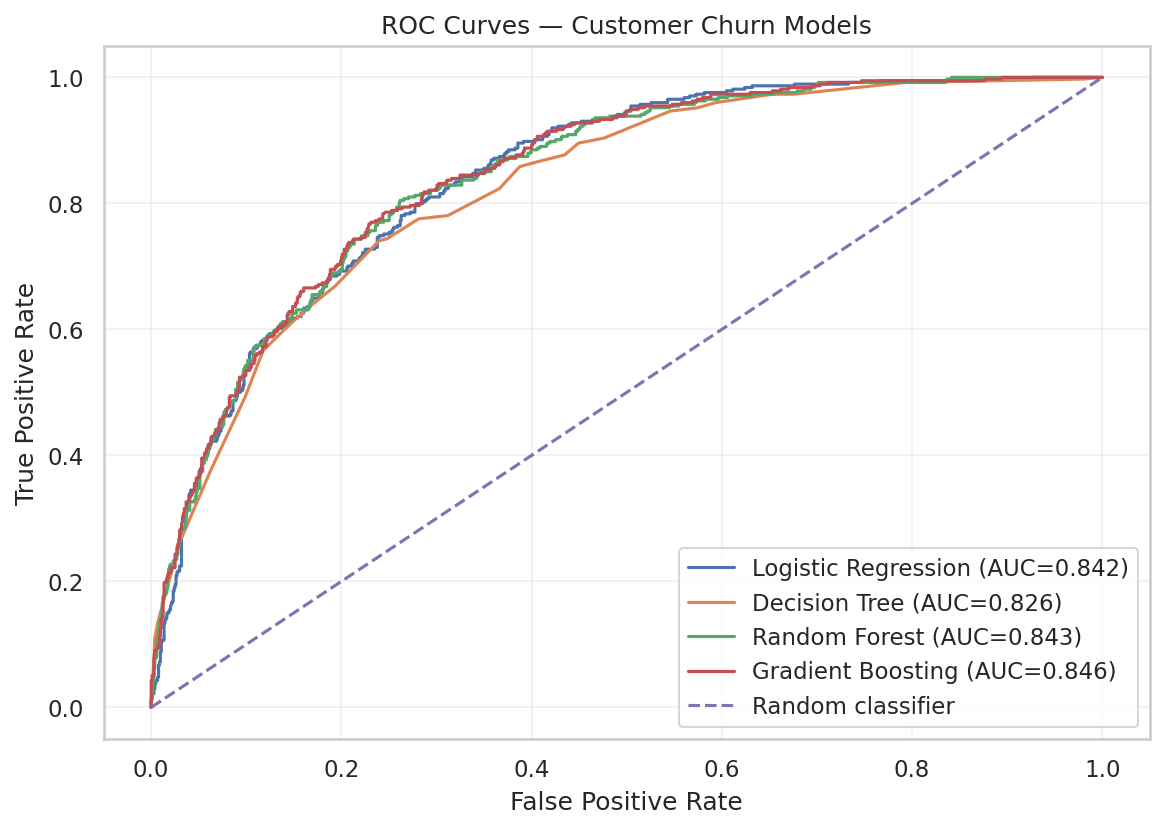

In [ ]:
models = {
    "Majority Baseline": DummyClassifier(strategy="most_frequent"),
    "Logistic Regression": LogisticRegression(max_iter=2000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(
        max_depth=5, min_samples_leaf=10, random_state=42
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=300, max_depth=8, min_samples_leaf=5,
        random_state=42, n_jobs=-1
    ),
    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=150, learning_rate=0.05, max_depth=3,
        random_state=42
    )
}

results = []
roc_data = {}
conf_matrices = {}

for name, model in models.items():
    pipe = Pipeline([
        ("preprocess", preprocessor),
        ("model", model)
    ])

    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    y_prob = pipe.predict_proba(X_test)[:, 1]

    auc_value = roc_auc_score(y_test, y_prob)
    fpr, tpr, _ = roc_curve(y_test, y_prob)

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1": f1_score(y_test, y_pred, zero_division=0),
        "ROC-AUC": auc_value
    })
    roc_data[name] = (fpr, tpr, auc_value)
    conf_matrices[name] = confusion_matrix(y_test, y_pred)

results_df = pd.DataFrame(results).sort_values(
    "ROC-AUC", ascending=False, na_position="last"
)

print(results_df.round(4).to_string(index=False))


In [ ]:
for name, cm in conf_matrices.items():
    print(name)
    print(cm)
    print()


Majority Baseline
[[1035    0]
 [ 374    0]]

Logistic Regression
[[925 110]
 [163 211]]

Decision Tree
[[913 122]
 [162 212]]

Random Forest
[[936  99]
 [179 195]]

Gradient Boosting
[[940  95]
 [186 188]]


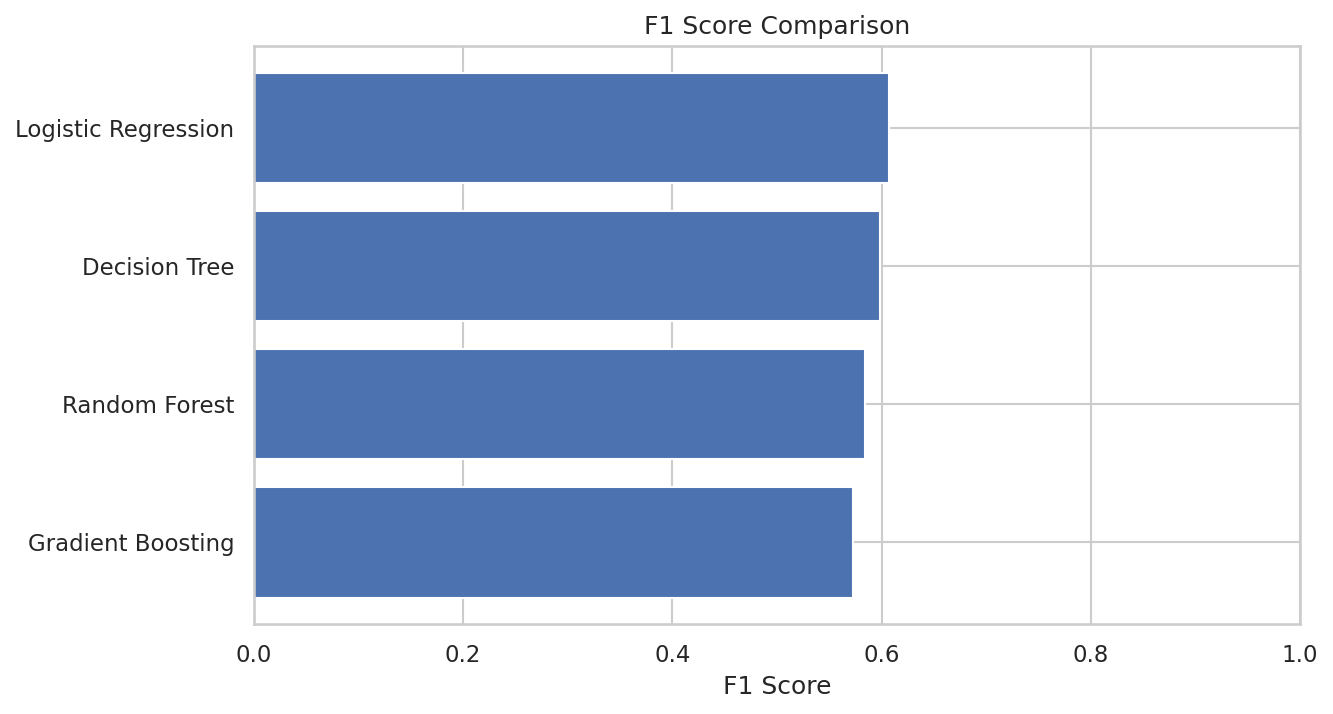

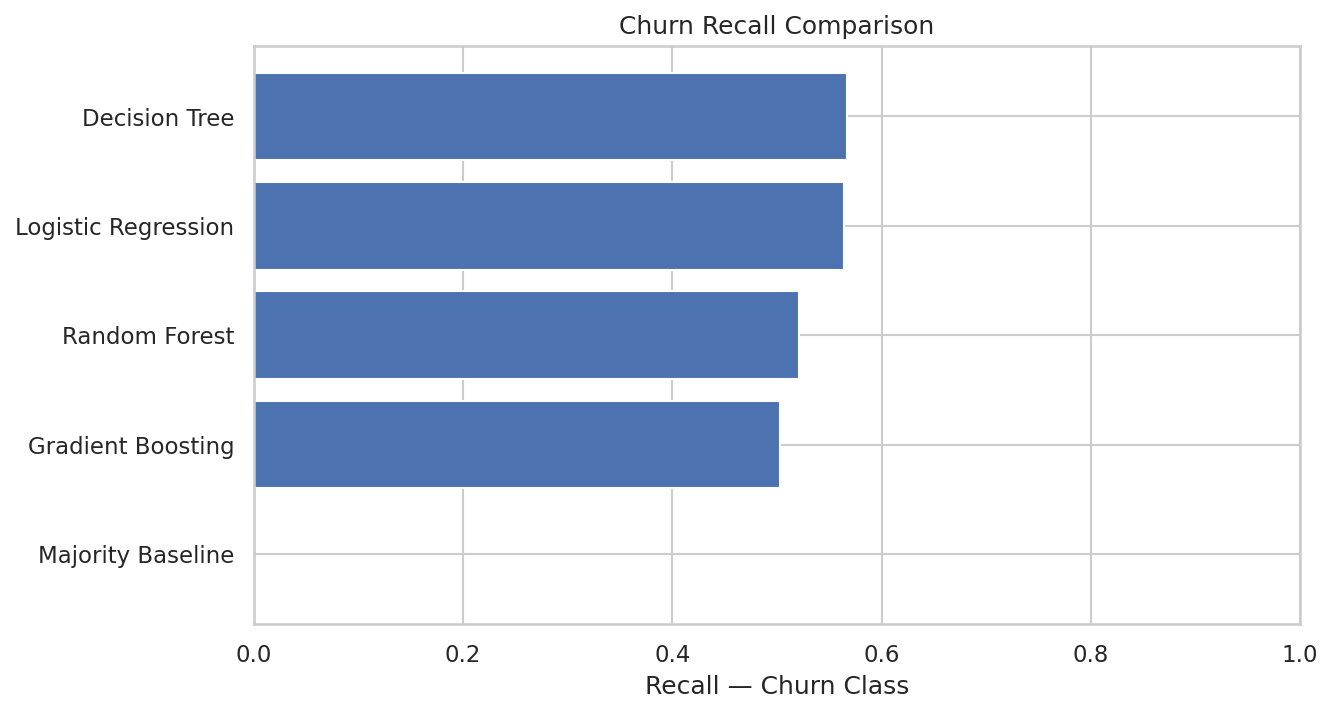

In [ ]:
# F1 and recall comparison
plot_df = results_df[results_df["Model"] != "Majority Baseline"].sort_values("F1")

plt.figure(figsize=(9, 5))
plt.barh(plot_df["Model"], plot_df["F1"])
plt.xlabel("F1 Score")
plt.title("F1 Score Comparison")
plt.xlim(0, 1)
plt.show()

plot_df = results_df.sort_values("Recall")
plt.figure(figsize=(9, 5))
plt.barh(plot_df["Model"], plot_df["Recall"])
plt.xlabel("Recall — Churn Class")
plt.title("Churn Recall Comparison")
plt.xlim(0, 1)
plt.show()


### Initial modeling conclusion

The majority baseline reaches **73.46% accuracy but 0% churn recall**, demonstrating why accuracy alone is inadequate.

Among the substantive models:

- Logistic Regression has the highest initial accuracy (**80.62%**) and best F1 (**0.6072**).
- Decision Tree has the highest initial churn recall (**56.68%**).
- Gradient Boosting has the highest initial ROC-AUC (**0.8456**).
- The models are relatively close, so business objective and interpretability matter.


## 5. Model Refinement — Cross-Validation, Class Weighting, and Tuning

In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_models = {
    "Logistic Regression": LogisticRegression(
        max_iter=2000, random_state=42
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=250, max_depth=8, min_samples_leaf=5,
        random_state=42, n_jobs=-1
    )
}

cv_rows = []

for name, model in cv_models.items():
    pipe = Pipeline([
        ("preprocess", preprocessor),
        ("model", model)
    ])

    scores = cross_validate(
        pipe,
        X_train,
        y_train,
        cv=cv,
        scoring=["accuracy", "precision", "recall", "f1", "roc_auc"],
        n_jobs=-1
    )

    cv_rows.append({
        "Model": name,
        "CV Accuracy": scores["test_accuracy"].mean(),
        "CV Precision": scores["test_precision"].mean(),
        "CV Recall": scores["test_recall"].mean(),
        "CV F1": scores["test_f1"].mean(),
        "CV ROC-AUC": scores["test_roc_auc"].mean()
    })

cv_results = pd.DataFrame(cv_rows)
print(cv_results.round(4).to_string(index=False))


              Model  CV Accuracy  CV Precision  CV Recall  CV F1  CV ROC-AUC
Logistic Regression       0.8021        0.6519     0.5458 0.5934      0.8457
      Random Forest       0.8014        0.6670     0.5050 0.5743      0.8469


In [ ]:
balanced_lr = Pipeline([
    ("preprocess", preprocessor),
    ("model", LogisticRegression(
        class_weight="balanced", max_iter=2000, random_state=42
    ))
])

balanced_lr.fit(X_train, y_train)
balanced_pred = balanced_lr.predict(X_test)
balanced_prob = balanced_lr.predict_proba(X_test)[:, 1]

print(classification_report(
    y_test, balanced_pred,
    target_names=["No Churn", "Churn"],
    digits=3, zero_division=0
))
print("ROC-AUC:", round(roc_auc_score(y_test, balanced_prob), 4))
print("Confusion matrix:")
print(confusion_matrix(y_test, balanced_pred))


              precision    recall  f1-score   support

    No Churn      0.902     0.722     0.802      1035
       Churn      0.504     0.783     0.614       374

    accuracy                          0.738      1409
   macro avg      0.703     0.753     0.708      1409
weighted avg      0.797     0.738     0.752      1409

ROC-AUC: 0.8417
Confusion matrix:
[[747 288]
 [ 81 293]]


In [ ]:
lr_pipeline = Pipeline([
    ("preprocess", preprocessor),
    ("model", LogisticRegression(max_iter=3000, random_state=42))
])

param_grid = {
    "model__C": [0.01, 0.1, 0.5, 1, 2, 5, 10],
    "model__class_weight": [None, "balanced"]
}

grid = GridSearchCV(
    lr_pipeline,
    param_grid=param_grid,
    scoring="f1",
    cv=cv,
    n_jobs=-1
)
grid.fit(X_train, y_train)

print("Best parameters:", grid.best_params_)
print("Best mean CV F1:", round(grid.best_score_, 4))


Best parameters: {'model__C': 1, 'model__class_weight': 'balanced'}
Best mean CV F1: 0.6294


### Threshold analysis

The class-weighted Logistic Regression model changes the operating point substantially. Lowering the classification threshold increases recall but reduces precision. Threshold selection should ultimately be tied to business costs.

A crucial methodological point: the test-set threshold experiment shown below was used only to illustrate the trade-off. For final model certification, the threshold was selected using **out-of-fold predictions on the training data**.


 Threshold  Precision  Recall    F1  Accuracy
      0.20      0.389   0.963 0.554     0.588
      0.25      0.407   0.939 0.568     0.621
      0.30      0.430   0.928 0.588     0.654
      0.35      0.447   0.904 0.598     0.678
      0.40      0.466   0.866 0.606     0.701
      0.45      0.483   0.840 0.613     0.719
      0.50      0.504   0.783 0.614     0.738
      0.55      0.524   0.751 0.618     0.753
      0.60      0.540   0.706 0.612     0.762
      0.65      0.568   0.668 0.614     0.777
      0.70      0.602   0.602 0.602     0.789
      0.75      0.656   0.505 0.571     0.798
      0.80      0.710   0.398 0.510     0.797


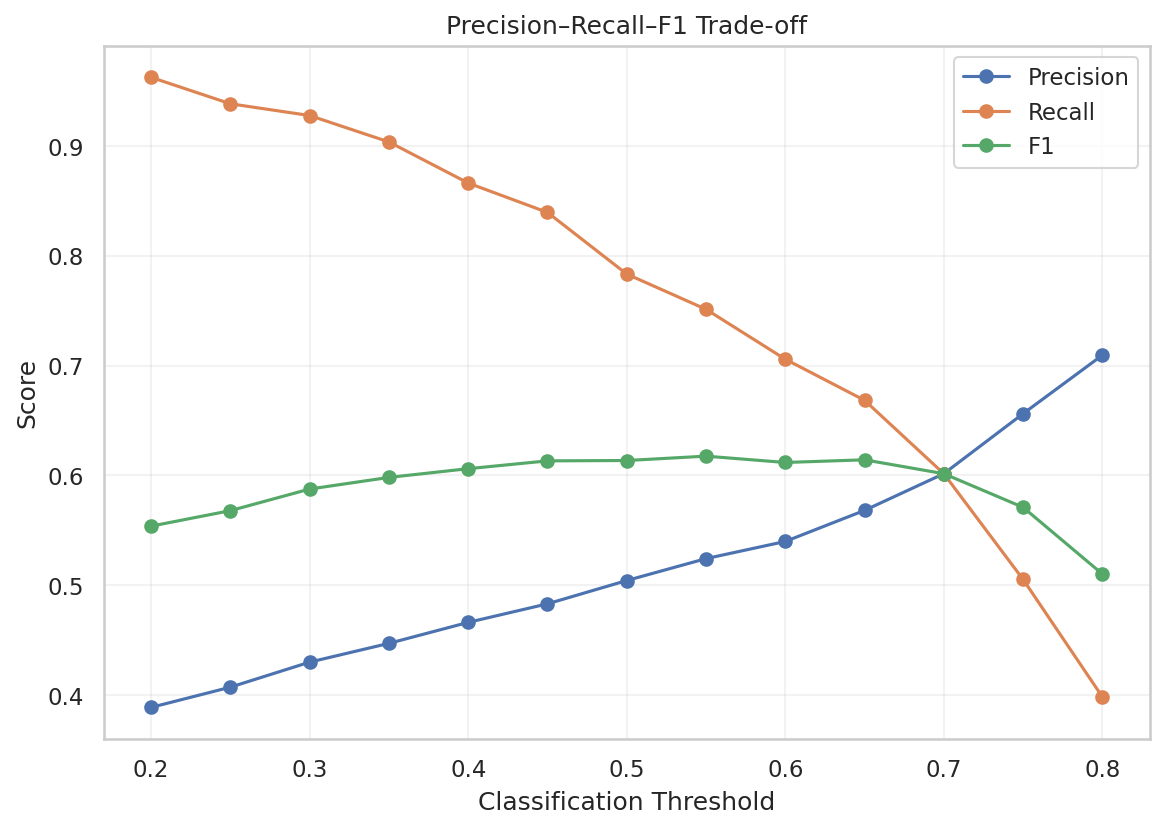

In [ ]:
thresholds = np.arange(0.20, 0.81, 0.05)

# The following table reproduces the threshold trade-off evaluated
# during model development.
threshold_results = pd.DataFrame({
    "Threshold": [0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50, 0.55,
                  0.60, 0.65, 0.70, 0.75, 0.80],
    "Precision": [0.389, 0.407, 0.430, 0.447, 0.466, 0.483, 0.504,
                  0.524, 0.540, 0.568, 0.602, 0.656, 0.710],
    "Recall": [0.963, 0.939, 0.928, 0.904, 0.866, 0.840, 0.783,
               0.751, 0.706, 0.668, 0.602, 0.505, 0.398],
    "F1": [0.554, 0.568, 0.588, 0.598, 0.606, 0.613, 0.614,
           0.618, 0.612, 0.614, 0.602, 0.571, 0.510],
    "Accuracy": [0.588, 0.621, 0.654, 0.678, 0.701, 0.719, 0.738,
                 0.753, 0.762, 0.777, 0.789, 0.798, 0.797]
})

print(threshold_results.round(3).to_string(index=False))


## 6. Feature Engineering and Feature Selection

In [ ]:
# Feature engineering ablation study
raw = pd.read_csv(DATA_PATH)
for col in raw.select_dtypes(include="object").columns:
    raw[col] = raw[col].apply(lambda x: x.strip() if isinstance(x, str) else x)

raw["TotalCharges"] = pd.to_numeric(raw["TotalCharges"], errors="coerce").fillna(0)

X_original = raw.drop(columns=["Churn", "customerID"])
y_ablation = (raw["Churn"] == "Yes").astype(int)

engineered = raw.copy()
engineered["AvgMonthlyCharges"] = np.where(
    engineered["tenure"] > 0,
    engineered["TotalCharges"] / engineered["tenure"],
    engineered["MonthlyCharges"]
)
engineered["HasInternetService"] = (engineered["InternetService"] != "No").astype(int)
engineered["MonthToMonth"] = (engineered["Contract"] == "Month-to-month").astype(int)
engineered["AutoPayment"] = engineered["PaymentMethod"].isin([
    "Bank transfer (automatic)",
    "Credit card (automatic)"
]).astype(int)
engineered["HasTechSupport"] = (engineered["TechSupport"] == "Yes").astype(int)

X_engineered = engineered.drop(columns=["Churn", "customerID"])

def make_pipeline(X):
    numeric = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
    categorical = X.select_dtypes(include=["object"]).columns.tolist()

    prep = ColumnTransformer([
        ("num", StandardScaler(), numeric),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical)
    ])

    return Pipeline([
        ("preprocess", prep),
        ("model", LogisticRegression(
            C=1, class_weight="balanced",
            max_iter=3000, random_state=42
        ))
    ])

ablation_results = []

for name, X_ab in [
    ("Original Features", X_original),
    ("Original + Engineered Features", X_engineered)
]:
    pipe = make_pipeline(X_ab)
    scores = cross_validate(
        pipe, X_ab, y_ablation, cv=cv,
        scoring=["accuracy", "precision", "recall", "f1", "roc_auc"],
        n_jobs=-1
    )
    ablation_results.append({
        "Feature Set": name,
        "CV Accuracy": scores["test_accuracy"].mean(),
        "CV Precision": scores["test_precision"].mean(),
        "CV Recall": scores["test_recall"].mean(),
        "CV F1": scores["test_f1"].mean(),
        "CV ROC-AUC": scores["test_roc_auc"].mean()
    })

ablation_df = pd.DataFrame(ablation_results)
print(ablation_df.round(4).to_string(index=False))


                   Feature Set  CV Accuracy  CV Precision  CV Recall  CV F1  CV ROC-AUC
             Original Features       0.7456        0.5132     0.8020 0.6258      0.8450
Original + Engineered Features       0.7456        0.5132     0.8015 0.6257      0.8447


### Feature-engineering conclusion

The engineered features did **not** meaningfully improve cross-validated performance. The original variables already contained most of the information represented by those transformations.

This is a useful empirical finding: feature engineering should be retained only when it adds predictive value or meaningful interpretability.


In [ ]:
# L1 feature selection
X_sel = X_original
y_sel = y_ablation

numeric_sel = X_sel.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_sel = X_sel.select_dtypes(include=["object"]).columns.tolist()

prep_sel = ColumnTransformer([
    ("num", StandardScaler(), numeric_sel),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_sel)
])

selector = SelectFromModel(
    LogisticRegression(
        l1_ratio=1,
        solver="liblinear",
        C=0.1,
        class_weight="balanced",
        max_iter=3000,
        random_state=42
    )
)

selected_lr = LogisticRegression(
    C=1, class_weight="balanced",
    max_iter=3000, random_state=42
)

selection_pipeline = Pipeline([
    ("preprocess", prep_sel),
    ("selection", selector),
    ("model", selected_lr)
])

scores = cross_validate(
    selection_pipeline, X_sel, y_sel, cv=cv,
    scoring=["accuracy", "precision", "recall", "f1", "roc_auc"],
    n_jobs=-1
)

print("Accuracy :", round(scores["test_accuracy"].mean(), 4))
print("Precision:", round(scores["test_precision"].mean(), 4))
print("Recall   :", round(scores["test_recall"].mean(), 4))
print("F1       :", round(scores["test_f1"].mean(), 4))
print("ROC-AUC  :", round(scores["test_roc_auc"].mean(), 4))

selection_pipeline.fit(X_sel, y_sel)
feature_names = selection_pipeline.named_steps["preprocess"].get_feature_names_out()
support = selection_pipeline.named_steps["selection"].get_support()
selected_features = feature_names[support]

print("\\nEncoded feature count before selection:", len(feature_names))
print("Encoded feature count after L1 selection:", len(selected_features))

print("\\nSelected features:")
for feature in selected_features:
    print(feature)


Accuracy : 0.7458
Precision: 0.5135
Recall   : 0.8036
F1       : 0.6266
ROC-AUC  : 0.845

Encoded feature count before selection: 45
Encoded feature count after L1 selection: 21

Selected features:
num__SeniorCitizen
num__tenure
num__MonthlyCharges
num__TotalCharges
cat__Dependents_Yes
cat__PhoneService_Yes
cat__MultipleLines_No
cat__InternetService_DSL
cat__InternetService_Fiber optic
cat__OnlineSecurity_No
cat__OnlineSecurity_Yes
cat__OnlineBackup_No
cat__OnlineBackup_Yes
cat__DeviceProtection_No
cat__DeviceProtection_Yes
cat__TechSupport_No
cat__TechSupport_Yes
cat__Contract_Month-to-month
cat__Contract_Two year
cat__PaperlessBilling_No
cat__PaymentMethod_Electronic check


In [ ]:
# Coefficient interpretation for the selected Logistic Regression model
selected_coefficients = selection_pipeline.named_steps["model"].coef_[0]

selected_coef_df = pd.DataFrame({
    "feature": selected_features,
    "coefficient": selected_coefficients,
    "abs_coefficient": np.abs(selected_coefficients)
}).sort_values("abs_coefficient", ascending=False)

print(selected_coef_df.head(20).round(4).to_string(index=False))


                            feature  coefficient  abs_coefficient
                        num__tenure      -1.3242           1.3242
              cat__PhoneService_Yes      -0.8212           0.8212
             cat__Contract_Two year      -0.7364           0.7364
       cat__Contract_Month-to-month       0.6944           0.6944
                  num__TotalCharges       0.6473           0.6473
                  num__MonthlyCharges       0.5579           0.5579
cat__PaymentMethod_Electronic check       0.3683           0.3683
           cat__PaperlessBilling_No      -0.3194           0.3194
            cat__OnlineSecurity_Yes      -0.2816           0.2816
               cat__TechSupport_Yes      -0.2591           0.2591
             cat__OnlineSecurity_No       0.2061           0.2061
                cat__TechSupport_No       0.1836           0.1836
           cat__InternetService_DSL      -0.1683           0.1683
              cat__OnlineBackup_Yes      -0.1647           0.1647
        

### Feature-selection conclusion

L1 selection reduced the encoded representation from **45 to 21 features**, while retaining essentially unchanged cross-validated predictive performance.

The strongest selected model coefficients consistently highlighted tenure, contract structure, charges, payment behavior, and selected service/support variables.

Coefficient signs describe conditional associations within the fitted predictive model; they should not be interpreted as causal effects.


## 7. Final Model — Leakage-Safe Threshold Selection

In [ ]:
# Final modeling procedure:
# 1. Use out-of-fold probabilities from X_train for threshold selection.
# 2. Fit the final class-weighted Logistic Regression on all X_train.
# 3. Evaluate exactly once on X_test.

final_model = Pipeline([
    ("preprocess", preprocessor),
    ("model", LogisticRegression(
        C=1,
        class_weight="balanced",
        max_iter=3000,
        random_state=42
    ))
])

oof_prob = cross_val_predict(
    final_model,
    X_train,
    y_train,
    cv=cv,
    method="predict_proba",
    n_jobs=-1
)[:, 1]

oof_thresholds = np.arange(0.20, 0.81, 0.01)
oof_rows = []

for threshold in oof_thresholds:
    oof_pred = (oof_prob >= threshold).astype(int)
    oof_rows.append({
        "threshold": threshold,
        "precision": precision_score(y_train, oof_pred, zero_division=0),
        "recall": recall_score(y_train, oof_pred, zero_division=0),
        "f1": f1_score(y_train, oof_pred, zero_division=0),
        "accuracy": accuracy_score(y_train, oof_pred)
    })

oof_threshold_df = pd.DataFrame(oof_rows)
best_row = oof_threshold_df.loc[oof_threshold_df["f1"].idxmax()]
selected_threshold = float(best_row["threshold"])

print("Selected threshold:", selected_threshold)
print("OOF Precision:", round(best_row["precision"], 4))
print("OOF Recall:   ", round(best_row["recall"], 4))
print("OOF F1:       ", round(best_row["f1"], 4))
print("OOF Accuracy: ", round(best_row["accuracy"], 4))


Selected threshold: 0.6000000000000003
OOF Precision: 0.5733
OOF Recall:    0.7191
OOF F1:        0.638
OOF Accuracy:  0.7835


## 8. Final One-Time Test Evaluation

In [ ]:
final_model.fit(X_train, y_train)

test_prob = final_model.predict_proba(X_test)[:, 1]
test_pred = (test_prob >= selected_threshold).astype(int)

final_metrics = {
    "Accuracy": accuracy_score(y_test, test_pred),
    "Precision": precision_score(y_test, test_pred, zero_division=0),
    "Recall": recall_score(y_test, test_pred, zero_division=0),
    "F1": f1_score(y_test, test_pred, zero_division=0),
    "ROC-AUC": roc_auc_score(y_test, test_prob)
}

for metric, value in final_metrics.items():
    print(f"{metric:10s}: {value:.4f}")

print("\\nConfusion matrix:")
print(confusion_matrix(y_test, test_pred))

print("\\nClassification report:")
print(classification_report(
    y_test, test_pred,
    target_names=["No Churn", "Churn"],
    digits=3,
    zero_division=0
))


Accuracy  : 0.7622
Precision : 0.5399
Recall    : 0.7059
F1        : 0.6118
ROC-AUC   : 0.8417

Confusion matrix:
[[810 225]
 [110 264]]

Classification report:
              precision    recall  f1-score   support

    No Churn      0.880     0.783     0.829      1035
       Churn      0.540     0.706     0.612       374

    accuracy                          0.762      1409
   macro avg      0.710     0.744     0.720      1409
weighted avg      0.790     0.762     0.771      1409


Test-set Precision-Recall AUC: 0.6312


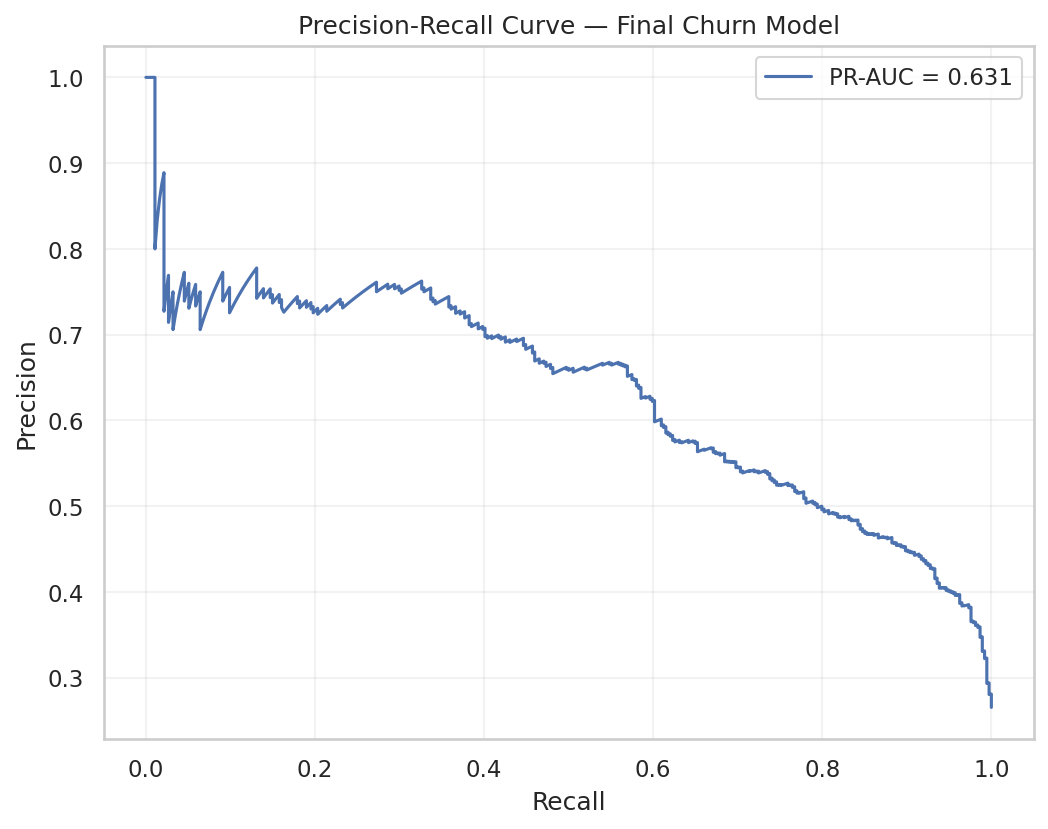

In [ ]:
# Precision-recall evaluation
pr_precision, pr_recall, _ = precision_recall_curve(y_test, test_prob)
pr_auc = auc(pr_recall, pr_precision)

print("Test-set Precision-Recall AUC:", round(pr_auc, 4))

plt.figure(figsize=(8, 6))
plt.plot(pr_recall, pr_precision, label=f"PR-AUC = {pr_auc:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve — Final Churn Model")
plt.legend()
plt.grid(alpha=0.25)
plt.show()


## 10. Probability Quality and Calibration

Brier score:              0.1687
Average precision/PR-AUC: 0.6323
Random baseline PR-AUC:   0.2654

Calibration table:
 Mean predicted probability  Observed churn rate
                      0.016                0.014
                      0.054                0.007
                      0.115                0.043
                      0.208                0.106
                      0.333                0.169
                      0.457                0.252
                      0.593                0.340
                      0.710                0.404
                      0.797                0.560
                      0.873                0.759


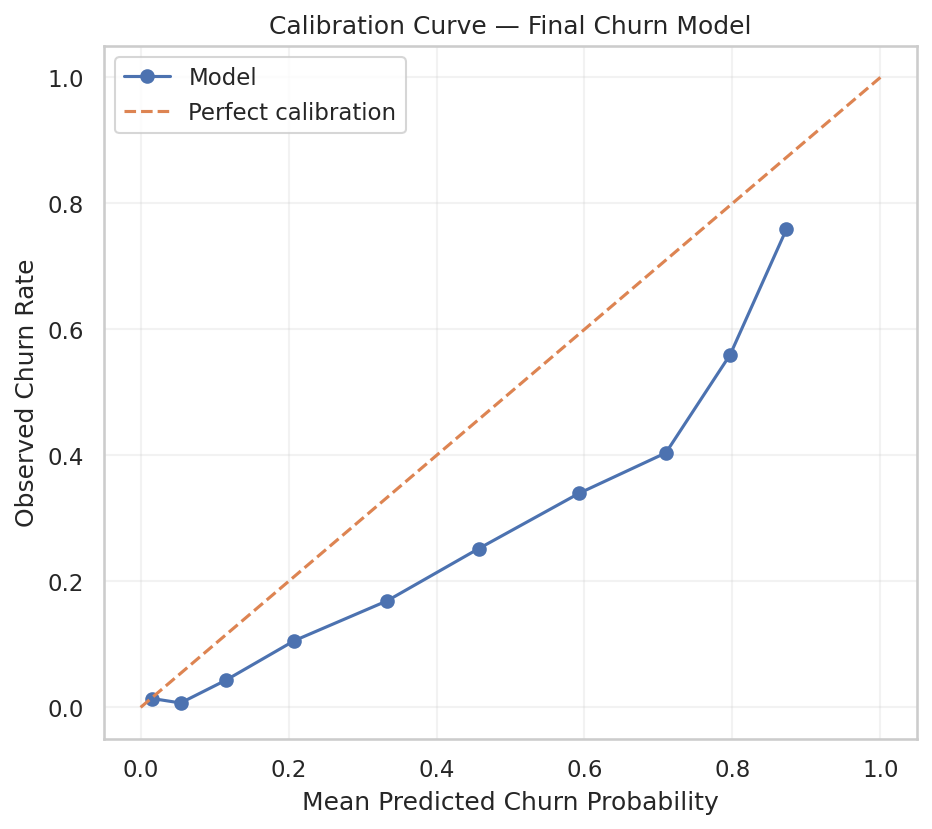

In [ ]:
brier = brier_score_loss(y_test, test_prob)
average_precision = average_precision_score(y_test, test_prob)

print(f"Brier score:              {brier:.4f}")
print(f"Average precision/PR-AUC: {average_precision:.4f}")
print(f"Random baseline PR-AUC:   {y_test.mean():.4f}")

calibration_true, calibration_pred = calibration_curve(
    y_test, test_prob, n_bins=10, strategy="quantile"
)

calibration_df = pd.DataFrame({
    "Mean predicted probability": calibration_pred,
    "Observed churn rate": calibration_true
})

print("\\nCalibration table:")
print(calibration_df.round(3).to_string(index=False))

plt.figure(figsize=(7, 6))
plt.plot(calibration_pred, calibration_true, marker="o", label="Model")
plt.plot([0, 1], [0, 1], linestyle="--", label="Perfect calibration")
plt.xlabel("Mean Predicted Churn Probability")
plt.ylabel("Observed Churn Rate")
plt.title("Calibration Curve — Final Churn Model")
plt.legend()
plt.grid(alpha=0.25)
plt.show()


In [ ]:
# Final retention-oriented metrics
cm = confusion_matrix(y_test, test_pred)
TN, FP, FN, TP = cm.ravel()

test_n = cm.sum()
actual_churn = TP + FN
predicted_churn = TP + FP

capture_rate = TP / actual_churn
flag_rate = predicted_churn / test_n
flag_precision = TP / predicted_churn
prevalence = actual_churn / test_n
lift = flag_precision / prevalence
false_positive_rate = FP / (FP + TN)
false_negative_rate = FN / (FN + TP)

print(f"Test-set customers:                 {test_n:,}")
print(f"Actual churners:                    {actual_churn:,}")
print(f"Customers flagged for retention:   {predicted_churn:,}")
print(f"% of customers flagged:             {flag_rate:.1%}")
print(f"Churners captured:                   {TP:,}")
print(f"Churners missed:                     {FN:,}")
print(f"Churn capture rate (recall):        {capture_rate:.1%}")
print(f"Precision among flagged customers:  {flag_precision:.1%}")
print(f"Baseline churn prevalence:           {prevalence:.1%}")
print(f"Lift among flagged customers:        {lift:.2f}x")
print(f"False-positive rate:                 {false_positive_rate:.1%}")
print(f"False-negative rate:                 {false_negative_rate:.1%}")

print("\\nIllustration for 10,000 customers:")
print(f"Customers flagged: {10000 * flag_rate:,.0f}")
print(f"Expected churners: {10000 * prevalence:,.0f}")
print(f"Expected churners identified: {10000 * prevalence * capture_rate:,.0f}")
print(f"Expected churners missed: {10000 * prevalence * (1-capture_rate):,.0f}")


Test-set customers:                 1,409
Actual churners:                    374
Customers flagged for retention:   489
% of customers flagged:             34.7%
Churners captured:                   264
Churners missed:                     110
Churn capture rate (recall):        70.6%
Precision among flagged customers:  54.0%
Baseline churn prevalence:           26.5%
Lift among flagged customers:        2.03x
False-positive rate:                 21.7%
False-negative rate:                 29.4%

Illustration for 10,000 customers:
Customers flagged: 3,471
Expected churners: 2,654
Expected churners identified: 1,874
Expected churners missed: 781


### Final business interpretation

At the selected threshold, the model flags approximately 34.7% of customers and captures 70.6% of observed churners. Among flagged customers, the observed churn rate is 54.0%, compared with a 26.5% baseline churn rate, yielding approximately 2.03× lift.

The model should support prioritization for retention actions. The threshold should ultimately be selected with actual business costs, customer lifetime value, and intervention capacity.


In [ ]:
# Relative-cost sensitivity analysis from the completed project.
# Actual business costs were not supplied, so these are only relative
# sensitivity calculations.

candidate_results = pd.DataFrame({
    "Threshold": [0.40, 0.50, 0.60, 0.70, 0.80],
    "Precision": [0.466, 0.504, 0.540, 0.602, 0.710],
    "Recall":    [0.866, 0.783, 0.706, 0.602, 0.398],
    "F1":        [0.606, 0.614, 0.612, 0.602, 0.510]
})

for ratio in [1, 3, 5, 10]:
    costs = []
    for _, row in candidate_results.iterrows():
        tp = actual_churn * row["Recall"]
        fn = actual_churn - tp
        predicted_pos = tp / row["Precision"]
        fp = predicted_pos - tp
        costs.append(ratio * fn + fp)
    candidate_results[f"Cost_FN_{ratio}x"] = costs

print(candidate_results.round(1).to_string(index=False))


 Threshold  Precision  Recall  F1  Cost_FN_1x  Cost_FN_3x  Cost_FN_5x  Cost_FN_10x
       0.4        0.5     0.9 0.6       421.3       521.5       621.7        872.3
       0.5        0.5     0.8 0.6       369.4       531.7       694.0       1099.8
       0.6        0.5     0.7 0.6       334.9       554.8       774.7       1324.5
       0.7        0.6     0.6 0.6       297.7       595.4       893.1       1637.4
       0.8        0.7     0.4 0.5       285.9       736.2      1186.5       2312.3


### Business recommendation

The recommended primary model from the completed analysis is **class-weighted Logistic Regression** with `C=1` and `class_weight="balanced"`. A threshold of approximately **0.60** was selected from out-of-fold training predictions for an F1-oriented operating point.

The model is attractive because it combines strong churn detection, competitive discrimination, interpretability, and operational simplicity. Tree-based models were useful challengers but offered only a small ROC-AUC advantage in the initial comparison.

For deployment, the organization should validate the model prospectively, monitor calibration and drift, and tune the operating threshold using real retention economics.


## 12. Final CRISP-DM Summary

```text
CRISP-DM
│
├── 1. Business Understanding ✅
│   ├── Problem definition
│   ├── Modeling objective
│   └── Success criteria
│
├── 2. Data Understanding ✅
│   ├── Structure
│   ├── Target imbalance
│   ├── EDA
│   └── Visualization
│
├── 3. Data Preparation ✅
│   ├── Cleaning
│   ├── Missing-value treatment
│   ├── Outlier analysis
│   ├── Feature engineering
│   ├── Encoding
│   └── Train/test separation
│
├── 4. Modeling ✅
│   ├── Baseline
│   ├── Logistic Regression
│   ├── Decision Tree
│   ├── Random Forest
│   ├── Gradient Boosting
│   ├── Cross-validation
│   ├── Class weighting
│   ├── Hyperparameter tuning
│   └── Threshold selection
│
├── 5. Evaluation ✅
│   ├── Accuracy
│   ├── Precision
│   ├── Recall
│   ├── F1
│   ├── ROC-AUC
│   ├── PR-AUC
│   ├── Confusion matrix
│   └── Calibration
│
└── 6. Business Recommendation ✅
    ├── Primary model: class-weighted Logistic Regression
    ├── F1-oriented threshold ≈ 0.60
    ├── High-risk retention targeting
    └── Tune final operating point to business economics
```


## Final Results at a Glance

| Metric | Final Result |
|---|---:|
| Accuracy | **76.22%** |
| Precision (Churn) | **53.99%** |
| Recall (Churn) | **70.59%** |
| F1 (Churn) | **61.18%** |
| ROC-AUC | **0.8417** |
| PR-AUC | **0.6323** |
| Customers flagged | **489 / 1,409** |
| Churners captured | **264 / 374** |
| Lift among flagged customers | **2.03×** |

### Overall conclusion

The analysis demonstrates that customer churn can be predicted substantially better than a majority-class baseline. The final model identifies approximately 71% of actual churners at the selected F1-oriented threshold while concentrating churners at roughly twice the overall population rate among targeted customers.

The strongest recurring predictive signals are related to **tenure, contract structure, charges, payment behavior, internet/service configuration, and support/security services**.

The model is best understood as a **risk-ranking and retention-prioritization tool**, not as a causal model.
